## Business Objective & Problem Statement

Credit card fraud causes billions in losses annually for banks, merchants, and consumers. The key challenges are:

- **Extreme class imbalance** — Fraudulent transactions represent only ~0.173% of total cases.
- **Anonymized features** (PCA-transformed V1–V28) — Limits direct interpretability but preserves privacy.
- **High cost of errors**:
  - False Negative (missed fraud) → Financial loss + customer trust damage
  - False Positive → Unnecessary customer friction + investigation costs

**Primary Objective**  
Develop a machine learning model that:
- Achieves **high recall on fraud class** (> 85–90%) to catch most fraudulent transactions
- Maintains **high precision** (> 85–90%) to minimize false alarms
- Optimizes **PR-AUC** (Precision-Recall AUC) as the core metric due to imbalance
- Uses simple, scalable methods (no heavy oversampling needed if possible)

**Secondary Objectives**
- Perform thorough EDA to understand feature behavior
- Compare baseline performance and improve via imbalance handling
- Provide clear, visual evaluation (confusion matrix, PR curve)
- Deliver actionable insights for real-world deployment

## Methodology

### Preprocessing
- Stratified train-test split (80/20) to preserve the original fraud ratio
- Standard scaling applied to **Time** and **Amount** features  
  (V1–V28 already PCA-transformed and roughly scaled)
- No additional feature engineering performed  
  (PCA transformation already provides strong, anonymized predictors)

### Imbalance Handling
- XGBoost configured with **scale_pos_weight ≈ 580**  
  (approximate ratio of non-fraud to fraud instances in training data)
- Primary evaluation focus on **PR-AUC** (Precision-Recall AUC)  
  and **recall at high precision** rather than overall accuracy

### Model
- **XGBoost Classifier** selected as the core model  
  (consistently ranks among top single-model performers on this dataset)
- Key hyperparameters used:
  - learning_rate = 0.05
  - max_depth = 6
  - n_estimators = 400
  - subsample = 0.8
  - colsample_bytree = 0.8
  - eval_metric = 'aucpr'
- Evaluation metrics:
  - Classification report (precision, recall, F1 per class)
  - Confusion marix
  - ROC-AUC
  - PR-AUC
-AUC, PR-AUC



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the Dataset 

In [2]:
df = pd.read_csv("creditcard.csv")
print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

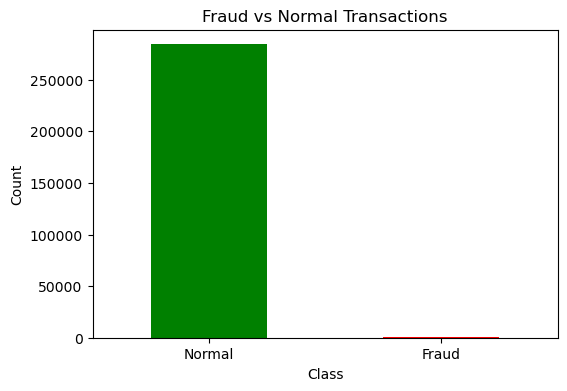

Normal Transaction: 284315
Fraud Detection: 492
Fraud Percentage: 0.173 %


In [14]:
# EDA - Understanding the Data
# 1. class distribution - how imbalanced is it?
plt.figure(figsize=(6,4))
df['Class'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Fraud vs Normal Transactions")
plt.xticks([0,1], ['Normal', 'Fraud'], rotation=0)
plt.ylabel('Count')
plt.show()

print("Normal Transaction:" , df['Class'].value_counts()[0])
print("Fraud Detection:", df['Class'].value_counts()[1])
print("Fraud Percentage:",round(df['Class'].value_counts()[1]/len(df)*100, 3),"%")

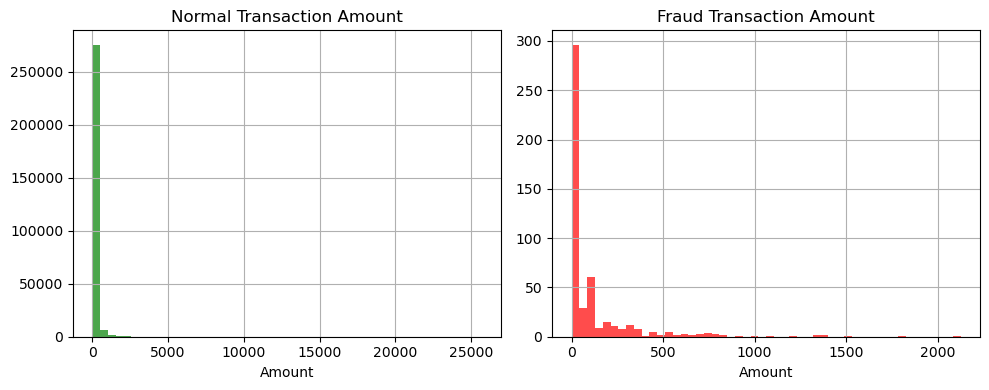

Average Normal Amount: 88.29
Average Fraud Amount: 122.21


In [17]:
# Transaction amount comparison - fraud vs normal
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df[df['Class']==0]["Amount"].hist(bins=50, color='green', alpha=0.7)
plt.title("Normal Transaction Amount")
plt.xlabel("Amount")

plt.subplot(1,2,2)
df[df['Class']==1]["Amount"].hist(bins=50, color='red', alpha=0.7)
plt.title("Fraud Transaction Amount")
plt.xlabel("Amount")

plt.tight_layout()
plt.show()

print("Average Normal Amount:",round(df[df['Class']==0]['Amount'].mean(), 2))
print("Average Fraud Amount:",round(df[df['Class']==1]['Amount'].mean(), 2))

In [18]:
# Check correlation of all features with Class (fraud)
correlation = df.corr()['Class'].sort_values()
print("Most NEGATIVE correlation with fraud:")
print(correlation.head(10))
print("\nMost POSITIVE correlation with fraud:")
print(correlation.tail(10))

Most NEGATIVE correlation with fraud:
V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

Most POSITIVE correlation with fraud:
V28      0.009536
V27      0.017580
V8       0.019875
V20      0.020090
V19      0.034783
V21      0.040413
V2       0.091289
V4       0.133447
V11      0.154876
Class    1.000000
Name: Class, dtype: float64


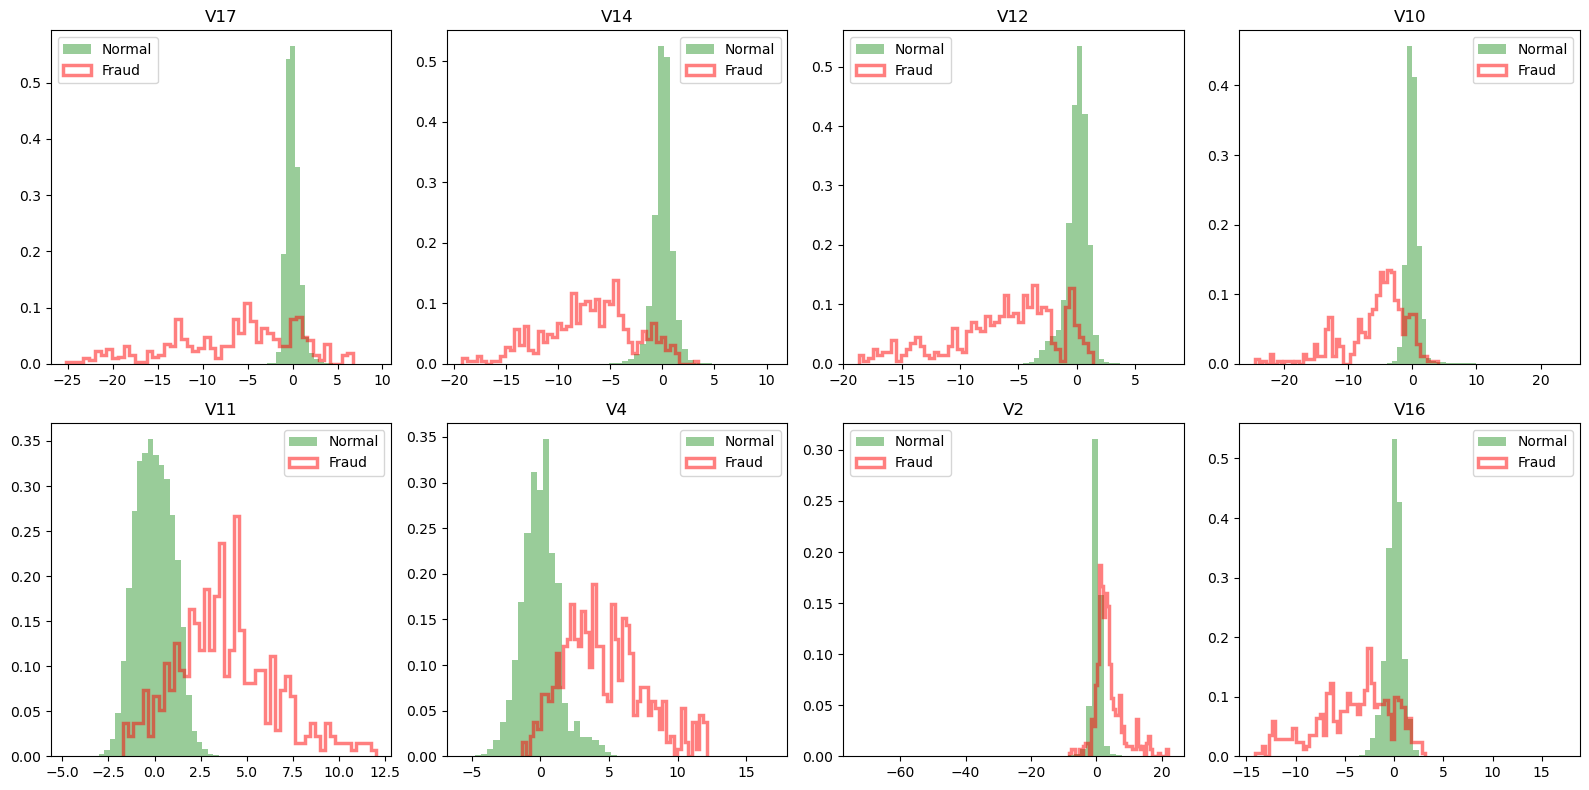

In [50]:
# Comparing top features between fraud and normal
fig, axes = plt.subplots(2, 4, figsize=(16,8))
axes = axes.flatten()

# V features most correlated with fraud
top_features = ['V17', 'V14', 'V12', 'V10', 'V11', 'V4', 'V2', 'V16']
for i, feature in enumerate(top_features):
    axes[i].hist(df[df['Class']==0][feature], bins=50, color='green', alpha=0.4, label='Normal', density=True)
    axes[i].hist(df[df['Class']==1][feature], bins=50, color='red', alpha=0.5, label='Fraud',histtype='step', density=True, linewidth=2.5)
    axes[i].set_title(feature)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Key Feature Distributions: Fraud vs Normal**

Histograms of the 8 most correlated V-features with fraud (sorted by correlation strength).  
- Fraud cases (red) show distinct shifts compared to normal transactions (green).  
- Strongest separation in **V14, V17, V12, V10** (negative correlation) and **V11, V4** (positive).

In [51]:
# Preparing data - Splitting + Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = df.sort_values('Time').reset_index(drop=True)
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=23)

scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

In [23]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Fraud ratio in train:", y_train.mean().round(5))
print("Fraud ratio in test:", y_test.mean().round(5))

Train shape: (227845, 30)
Test shape: (56962, 30)
Fraud ratio in train: 0.00173
Fraud ratio in test: 0.00172


In [24]:
# Calculate scale_pos_weight = ( ~ non fraud / fraud count)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'Non-Fraud Count: {neg_count:,}')
print(f'Fraud Count: {pos_count:,}')
print(f'scale_pos_weight: {scale_pos_weight:.1f}')

Non-Fraud Count: 227,451
Fraud Count: 394
scale_pos_weight: 577.3


In [32]:
# Training XGBoost with imbalance handling
import xgboost as xgb

model = xgb.XGBClassifier(
    scale_pos_weight = scale_pos_weight,
    eval_metric = 'aucpr',
    random_state = 23,
    n_estimators = 400,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    tree_method = 'hist',
    enable_categorical = False,
    verbosity = 1
)

In [33]:
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose = False)
print("Training completed!")

Training completed!


In [34]:
# Prediction and Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [35]:
# Basic metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

In [37]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.91      0.83      0.87        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



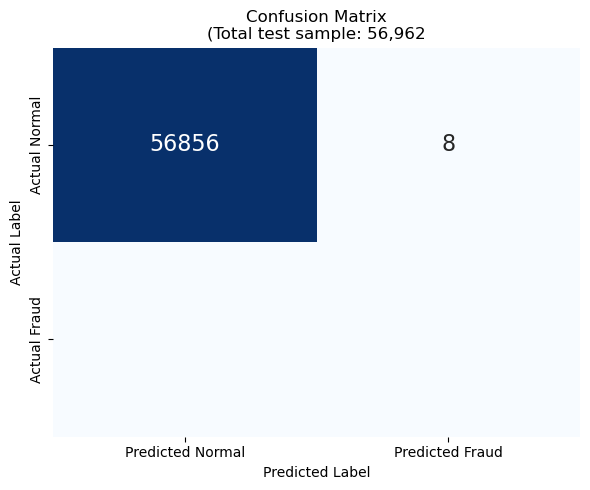

True Negatives  (correct normal) : 56,856
False Positives (false alarms)   : 8
False Negatives (missed fraud)    : 17
True Positives  (caught fraud)    : 81


In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Normal', 'Predicted Fraud'],
            yticklabels=['Actual Normal', 'Actual Fraud'], cbar=False,annot_kws={"size": 16})
plt.title('Confusion Matrix\n(Total test sample: {:,}'.format(len(y_test)))
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Negatives  (correct normal) :", f"{tn:,}")
print("False Positives (false alarms)   :", f"{fp:,}")
print("False Negatives (missed fraud)    :", f"{fn:,}")
print("True Positives  (caught fraud)    :", f"{tp:,}")

In [41]:
print(f"ROC-AUC    :{roc_auc_score(y_test, y_prob):.5f}")

ROC-AUC    :0.97804


In [40]:
# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"PR-AUC (AUC-PR): {pr_auc:.5f}")

PR-AUC (AUC-PR): 0.84220


# Final Model Performance Highlights
•  Test set size: 56,962 transactions (~20% of full data)
•  Fraud cases in test: 98
•  Results with default threshold (0.5):
	•  Recall (Fraud): 83% → caught 81 out of 98 fraudulent transactions
	•  Precision (Fraud): 91% → when the model says fraud, it’s correct 91% of the time
	•  F1-score (Fraud): 0.87 → excellent balance
	•  False Positives: only 8 (extremely low false alarm rate ≈ 0.014%)
	•  False Negatives: 17 missed frauds
	•  ROC-AUC: 0.9788
	•  PR-AUC: 0.8422 